In [17]:
import numpy as np
import scipy.sparse as ss
import matplotlib.pyplot as plt

In [36]:
# define Hamiltonian
def construct_H(N, L, V0, R):
    a = L / N
    indices = np.arange(N)

    # construct T
    diags = np.ones(N)
    off_diags = diags[1:]
    T = ss.diags([off_diags, -2 * diags, off_diags], [-1, 0, 1], format='lil')
    # fill corners because of BCs
    T[0, N - 1] = 1
    T[N - 1, 0] = 1
    # multiply by lattice spacing factor and format as csr
    T = (-1 / a**2 * T).tocsr().astype(np.complex128)

    # construct V
    distances = np.abs(indices - N // 2)
    vs = V0 * np.exp(-(distances * a)**2 / R**2)
    V = ss.diags(vs, format='csr', dtype=np.complex128)
    
    H = T + V
    return H

In [35]:
# grab eigenpairs
def get_eigenpairs(N, L, V0, R, k_num=1):
    Ls = np.atleast_1d(L)
    temp_H = construct_H(N, Ls[0], V0, R)
    eigenvalues = np.zeros((len(Ls), k_num), dtype=np.float64)
    eigenvectors = np.zeros((len(Ls), k_num, temp_H.shape[0]), dtype=np.complex128)
    
    sparse = ss.issparse(temp_H)
    for i, Li in enumerate(Ls):
        H = construct_H(N, Li, V0, R)
        if sparse: # use sparse solver (ARPACK)
            eigvals, eigvecs = ss.linalg.eigsh(H, k=k_num, which='SA')
        else: # use dense solver (LAPACK)
            eigvals, eigvecs = scipy.linalg.eigh(H)
        sort_indices = np.argsort(eigvals)
        eigenvalues[i] = eigvals[sort_indices][:k_num]
        eigenvectors[i] = eigvecs[:, sort_indices][:, :k_num].T
    return eigenvalues, eigenvectors

In [37]:
# construct Hamiltonian M after adjusting A, B
def M(A, B, C, L):
    # force hermiticity
    A = .5 * (A + A.conj().T)
    B = .5 * (B + B.T)
    C = .5 * (C + C.conj().T)
    
    # if L is given as a scalar, just return A + LB
    # if L is given as a jnp array, return [M(L1), ..., M(LN)]
    a = 1.0
    if jnp.isscalar(L):
        return A - (1 / L**2) * B - jnp.exp(-a * L) * C
    else:
        # reshape g array so that it has dimension (:, 1, 1) for broadcasting with A, B
        return A - (1 / L[:, None, None]**2) * B - jnp.exp(-a * L[:, None, None]) * C

# get the k-lowest eigenvalues of M (or Ms if M is given as a batch of matrices)
def get_eigenvalues(M, k):
    # M might not be sparse during construction, so use jnp instead of ss
    if M.ndim == 2:
        eigvals, eigvecs = jnp.linalg.eigh(M)
        eigvals, eigvecs = eigvals[:k], eigvecs[:, :k].T
    elif M.ndim == 3:
        #  jnp eig will vectorize, so pick k lowest eigs for each M_i if given multiple Ms
        eigvals, eigvecs = jnp.linalg.eigh(M)
        eigvals, eigvecs = eigvals[:, :k], eigvecs[:, :, :k].swapaxes(1,2)
    else:
        raise ValueError("Input must be a 2D matrix or 3D batch of matrices")
    return eigvals, eigvecs

# loss function
# mean squared error of the predicted eigenvalues to the true eigenvalues
def loss(A, B, C, Ls, Es):
    """
    mean_squared_error = 1 / N \sum_i |E_i - E_i_true|^2
    non_plateau_punishment = 1 / N \sum_i 
    """
    # if Es are given as a 1D array of scalars, reshape to 2D array:
    # [E1, E2, E3] -> [[E1], [E2], [E3]]
    if Es.ndim == 1:
        Es = Es.reshape(-1, 1)
    # number of lowest-eigenvalues to take is given by shape of Es
    k = Es.shape[1]
    Ms = M(A, B, C, Ls)
    eigvals, eigvecs = get_eigenvalues(Ms, k)

    # mean squared difference
    mean_square_diff = jnp.mean(jnp.abs(eigvals - Es)**2)

    # punish non-plateau behavior
    dl = Ls[-1] - Ls[-2]
    end = 20.0
    Mi, Mf = M(A, B, C, end - dl), M(A, B, C, end + dl)
    plat_energiesi, plat_energiesf = get_eigenvalues(Mi, k), get_energies(Mf, k)
    non_plateau = jnp.abs((Mf - M1) / (2 * dl))
    
    # l2 regularization
    l2 = jnp.mean(jnp.abs(A)**2) + jnp.mean(jnp.abs(B)**2) + jnp.mean(jnp.abs(C)**2)
    
    # punish non-smoothness of eigenvectors
    # 
    non_smooth = eigvecs

    loss = mean_square_diff + non_plateau + l2 + non_smooth
    return loss

# define general Adam-update for complex parameters and real-loss functions
def adam_update(parameter, vt, mt, t, grad, eta=1e-2, beta1=0.9, beta2=0.999, eps=1e-8, absmaxgrad=1e3):
    # conjugate the gradient and cap it with absmaxgrad
    gt = jnp.clip(grad.real, -absmaxgrad, absmaxgrad) - 1j * jnp.clip(grad.imag, -absmaxgrad, absmaxgrad)
    # compute the moments (momentum and normalizing) step parameters
    vt = beta1 * vt + (1 - beta1) * gt
    mt = beta2 * mt + (1 - beta2) * jnp.abs(gt)**2
    
    # bias correction
    vt_hat = vt / (1 - beta1 ** (t + 1))
    mt_hat = mt / (1 - beta2 ** (t + 1))
    
    # step parameter
    parameter = parameter - eta * vt_hat / (jnp.sqrt(mt_hat) + eps)
    return parameter, vt, mt

def train(A, B, epochs, gs, Es, store_loss=100):
    # construct vt and mt moments
    shape = A.shape
    if shape != B.shape:
    raise ValueError("A and B must have the same shape")
    vt_A = jnp.zeros(shape, dtype=jnp.complex128)
    mt_A = jnp.zeros(shape, dtype=jnp.complex128)
    
    vt_B = jnp.zeros(shape, dtype=jnp.complex128)
    mt_B = jnp.zeros(shape, dtype=jnp.complex128)
    
    # create array to store loss at epoch t
    losses = np.zeros(epochs // store_loss)
    
    # jit the loss function so that it's significantly quicker to call
    jit_loss = jax.jit(loss)
    
    # define the gradient function
    grad_loss = jax.grad(jit_loss, argnums=(0, 1))
    
    # update the parameter for every epoch
    for t in range(epochs):
    gt = grad_loss(A, B, gs, Es)
    A, vt_A, mt_A = adam_update(A, vt_A, mt_A, t, gt[0])
    B, vt_B, mt_B = adam_update(B, vt_B, mt_B, t, gt[1])
    
    if t % store_loss == 0:
      losses_at_t = jit_loss(A, B, gs, Es)
      losses[t // store_loss] = losses_at_t
    
    # force hermiticity one last time
    A = .5 * (A + A.conj().T)
    B = .5 * (B + B.conj().T)
    
    return A, B, losses

SyntaxError: invalid syntax (4033040328.py, line 54)

In [32]:
# set vars
N, V0, R = 128, -4.0, 2.0
Ls = np.linspace(0.1, 20.0, 150)

In [33]:
eigvals, _ = get_eigenpairs(N, Ls, V0, R)

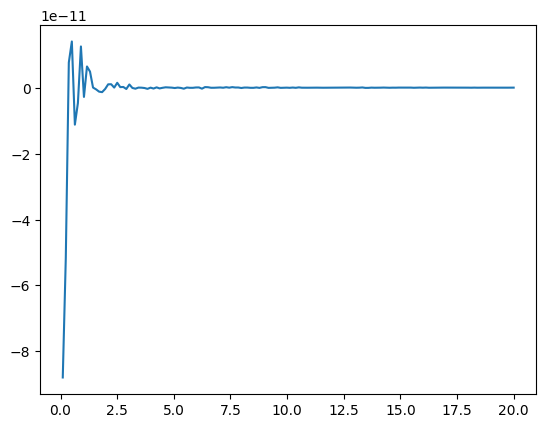

In [34]:
# plot results
fig, ax = plt.subplots()
ax.plot(Ls, eigvals[:, 0])
plt.show()